In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats
import figure_prep
pd.options.mode.use_inf_as_na = True

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_18016\385418557.py:20: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [3]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [4]:
primary_df_interp_10_3 = primary_df_interp[primary_df_interp['Concentration'] == '10-3']
primary_df_interp_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Collective'] == 'Group']
primary_df_interp_WT_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Genotype'] == 'WT']
primary_df_interp_Trh_10_3 = primary_df_interp_10_3[primary_df_interp_10_3['Genotype'] == 'Trh']

In [5]:
primary_df_interp_10_4 = primary_df_interp[primary_df_interp['Concentration'] == '10-4']
primary_df_interp_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Collective'] == 'Group']
primary_df_interp_WT_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Genotype'] == 'WT']
primary_df_interp_Trh_10_4 = primary_df_interp_10_4[primary_df_interp_10_4['Genotype'] == 'Trh']

In [6]:
primary_df_interp_10_5 = primary_df_interp[primary_df_interp['Concentration'] == '10-5']
primary_df_interp_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Collective'] == 'Group']
primary_df_interp_WT_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Genotype'] == 'WT']
primary_df_interp_Trh_10_5 = primary_df_interp_10_5[primary_df_interp_10_5['Genotype'] == 'Trh']

# Pentyl Acetate and 1-Pentanol

In [7]:
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']
df_PA_104 = pd.concat([df_WT_PA_104, df_Trh_PA_104])

In [8]:
df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']
df_1P_102 = pd.concat([df_WT_1P_102, df_Trh_1P_102])

# Methyl Butyrate and Benzaldehyde

In [9]:
df_MB = primary_df_interp[(primary_df_interp['Odour'] == 'MB')]
df_104_MB = df_MB[(df_MB['Concentration'] == '10-4')]
df_103_MB = df_MB[(df_MB['Concentration'] == '10-3')]

In [10]:
df_BA = primary_df_interp[(primary_df_interp['Odour'] == 'BA')]
df_104_BA = df_BA[(df_BA['Concentration'] == '10-4')]
df_103_BA = df_BA[(df_BA['Concentration'] == '10-3')]

# Kir Crosses

In [11]:
df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']
df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]

# TNT Crosses

In [12]:
df_csd_tnt = primary_df_interp[(primary_df_interp['Genotype'] == 'CSDxTNTe') | 
                           (primary_df_interp['Genotype'] == 'CSDxTNTi')]

df_trh_tnt = primary_df_interp[(primary_df_interp['Genotype'] == 'TrhxTNTe') | 
                           (primary_df_interp['Genotype'] == 'TrhxTNTi')]

In [13]:
df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]

In [14]:
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

In [15]:
df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')
                            | (primary_df_interp['Genotype'] == 'TNTexuPN')
                            | (primary_df_interp['Genotype'] == 'TNTixuPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

In [16]:
df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\figure_prep.py:3174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\figure_prep.py:3179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


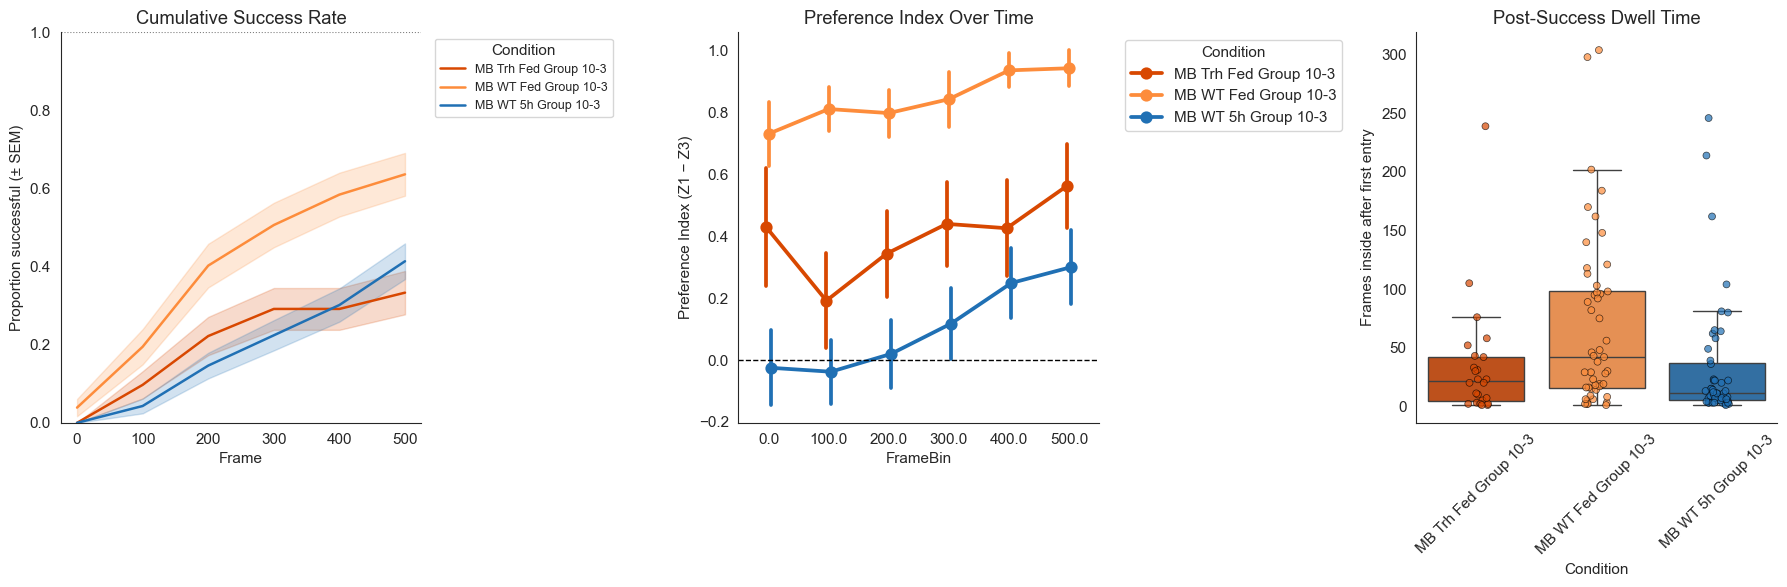

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\figure_prep.py:741: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_success = g.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\figure_prep.py:748: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_r = g.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\Structured\figure_prep.py:741: FutureWarning: DataFrameGroupBy.app

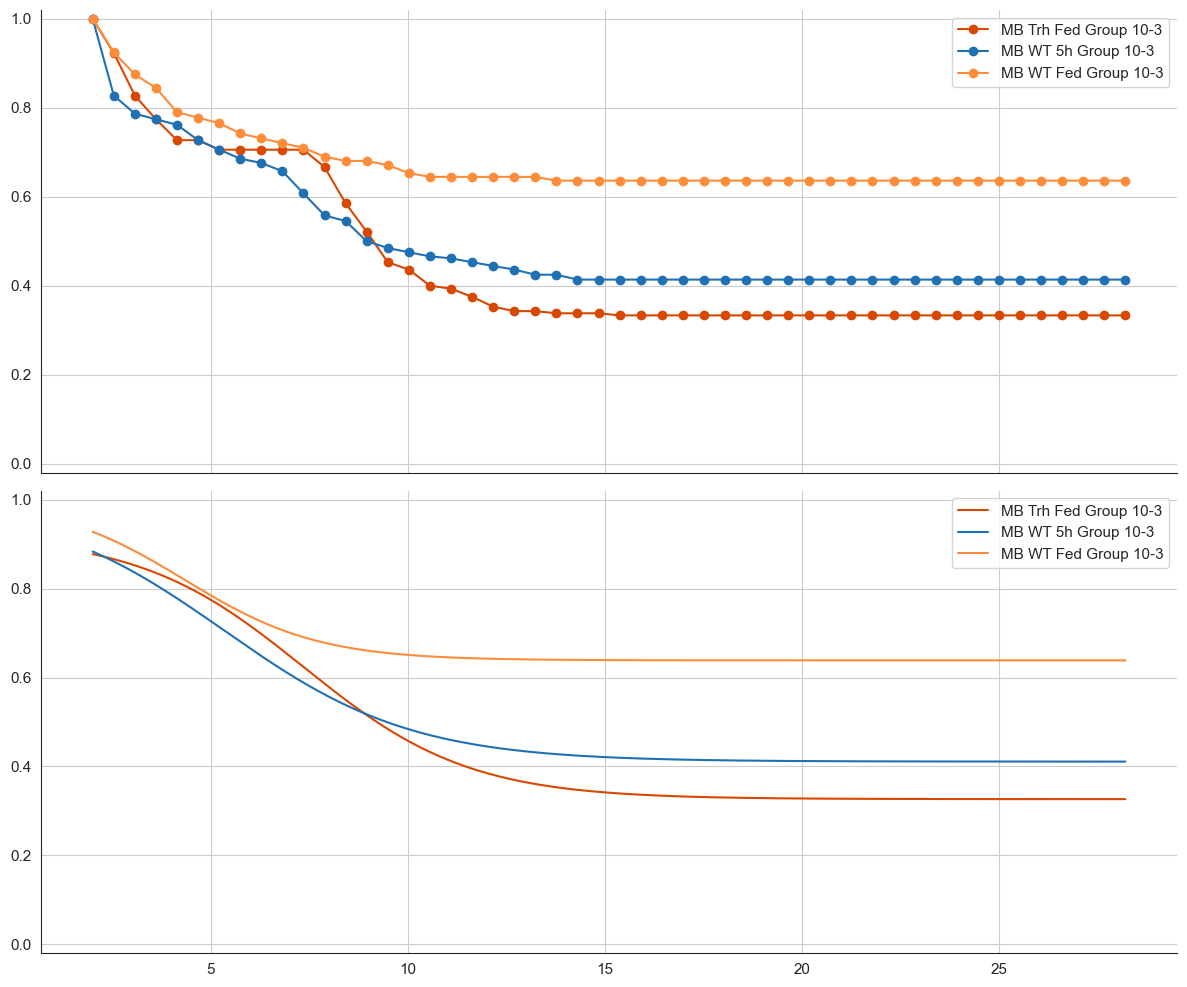

In [19]:
plotting_df = df_103_MB
_,_,_ = figure_prep.plot_behavior_summary_overtime(plotting_df)
_ = figure_prep.plot_probability_and_bootstrap_logistic(plotting_df, save_csv=False)